# Recording log from QDSpy log and `smh` headers

This notebook read and parses a stimulus log file (`QDSpy.ini`) and the ScanM header files (`*.smh`) and writes thie contained information in pandas DataFrames as well as `.csv` files for further processing.

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from datetime import datetime, time 
from pathlib import Path
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

Set path to log file name and folder with `.smh` files

In [4]:
LOG_PATH = Path("../data/20181011_182540.log")
SMH_PATH = Path("../data/smh/")

## Parse QDSpy log file
Extract information from log file, resulting in a list of stimulus presentations (`stims`, list of dictionaries) will timing information and stimulus parameters

In [5]:
nLinesTotal = 0
nLinesData = 0
nLinesErr = 0
nErr = 0
isStimStarted = False
stims = []
nStims = 0

with open(LOG_PATH, "r", encoding="utf-8", errors="ignore") as fLog:
    for line in fLog:
        # Extract elements of each line
        nLinesTotal += 1
        sDateTime = line[:15]
        sInfoType = line[15:23].strip().upper()
        sMsg = line[23:len(line) -1].strip()

        # Convert time stamp into a datetime        
        dt = datetime.strptime(sDateTime, "%Y%m%d_%H%M%S")
        if nLinesTotal == 1:
            # First line; take as start time
            dt_log_start = dt
            dt_last_end = dt_log_start

        # Filter for relevant information
        if sInfoType not in ["DATA"]:
            # Ignore filed
            continue

        # Convert data line into dictionary 
        sMsg = sMsg.replace("'", "\"")
        sMsg = sMsg.replace("\\\\", "/")
        sMsg = sMsg.replace("(", "[")
        sMsg = sMsg.replace(")", "]")

        try:
            data = json.loads(sMsg)
        except json.JSONDecodeError as e:
            # JSON parsing failed
            print(f"ERROR: parsing line {nLinesTotal-1} failed:")
            print(f"'{sMsg}'")
            nLinesErr += 1
            data = None

        # Get stimulus start/stop pairs
        try:
            stimState = data["stimState"].upper()
        except KeyError:
            stimState = None        


        if stimState:
            # Data contains stimulus information
            if stimState == "STARTED":
                if isStimStarted:
                    print("ERROR: Two consecutive stimulus starts")
                    nErr += 1

                isStimStarted = True
                iLineLastStart = nLinesData
                dt_start = dt
                t_diff = (dt -dt_log_start).total_seconds()
                t_diff_last = (dt -dt_last_end).total_seconds()
                stimInfo = dict(
                    {"index": nStims, 
                     "stimFileName": Path(data["stimFileName"]).name,
                     "stimPath": str(Path(data["stimFileName"]).parent),
                     "stimMD5": data["stimMD5"],
                     "t_abs_s": t_diff,
                     "t_since_last_s": t_diff_last,
                     "t_start": dt.time()}

                )

            elif stimState in ["ABORTED", "FINISHED"]:
                if isStimStarted:
                    # Check if stimulus end belongs to stimulus start
                    fn = str(Path(stimInfo["stimPath"], stimInfo["stimFileName"])).replace("\\", "/")
                    if not data["stimFileName"] == fn:
                        print("ERROR: File paths for stimulus start and end differ")
                        nErr += 1

                    # Append stimulus list entry
                    dt_last_end = dt
                    t_diff = (dt -dt_start).total_seconds()
                    stimInfo.update(
                        {"aborted": stimState == "ABORTED",
                         "t_end": dt.time(),
                         "t_dur_s": t_diff}
                    )
                    stims.append(stimInfo)
                    nStims += 1
                    isStimStarted = False
                else:
                    print("ERROR: Stimulus end w/o start?")    
                    nErr += 1
        else:
            # Other information
            try:
                _ = data["nFrames"]
                isFrameInfo = True
            except KeyError:
                isFrameInfo = False

            if isFrameInfo:
                # Information about stimulus presentation statistics
                stims[nStims -1].update(
                    {"t_dur_s_calc": data["nFrames"] /data["avgFreq_Hz"],
                     "nDroppedFrames": data["nDroppedFrames"]}
                )
            else:            
                if nLinesData > iLineLastStart and nLinesData < iLineLastStart +3:
                    # Last start was only up to 2 lines before
                    stims[nStims -1].update(
                        {"params": data}
                    )
                else:
                    print("ERROR: Data w/o start??")    
                    nErr += 1

        '''
        print(f"line #{nLinesData}:")
        print(dt)
        print(data)
        '''
        nLinesData += 1

    print(f"{nLinesData} of {nLinesTotal} line(s) extracted.")
    print(f"{nLinesErr} line(s) failed parsing, {nErr} error(s) occurred post-processing.")    

280 of 1401 line(s) extracted.
0 line(s) failed parsing, 0 error(s) occurred post-processing.


Print stimulus presentation table

In [6]:
print("  #    start   t [s] gap [s] dur [s] nFr/frq abort stimulus name")
print("--- -------- ------- ------- ------- ------- ----- ")

for stim in stims:
    s = f"{stim["index"]:3d} {stim["t_start"]} {stim["t_abs_s"]:7.0f} "
    s += f"{stim["t_since_last_s"]:7.0f} {stim["t_dur_s"]:7.0f} {stim["t_dur_s_calc"]:7.0f} "  
    s += f"{"  y   " if stim["aborted"] else "      "} "
    s += f"`{Path(stim["stimFileName"]).name}`"

    print(s)

  #    start   t [s] gap [s] dur [s] nFr/frq abort stimulus name
--- -------- ------- ------- ------- ------- ----- 
  0 12:57:03       3       3       0       0        `__autorun_default_DO_NOT_DELETE`
  1 13:19:26    1346    1343     189     189   y    `DN`
  2 13:22:39    1539       4      12      12   y    `DS`
  3 13:22:54    1554       3     169     169   y    `DN`
  4 13:25:44    1724       1      31      30   y    `DS`
  5 13:26:16    1756       1     147     146   y    `DN`
  6 13:28:44    1904       1     100     100   y    `DS`
  7 13:31:24    2064      60     101     101        `DS`
  8 13:33:42    2202      37     165     165        `Chirp`
  9 13:37:07    2407      40     618     618        `MouseCam_Right`
 10 13:48:54    3114      89     101     101        `DS`
 11 13:51:55    3295      80     101     101        `DS`
 12 13:54:07    3427      31     165     165        `Chirp`
 13 13:58:01    3661      69     618     618        `MouseCam_Right`
 14 14:08:30    4290      

Example for information contained in one stimulus presentation entry

In [7]:
stims[1]

{'index': 1,
 'stimFileName': 'DN',
 'stimPath': 'C:\\Users\\AGEuler\\Documents\\QDSpy\\Stimuli\\Katrin\\RGCs',
 'stimMD5': '521d77a52eff75053da309ada99d1156',
 't_abs_s': 1346.0,
 't_since_last_s': 1343.0,
 't_start': datetime.time(13, 19, 26),
 'aborted': True,
 't_end': datetime.time(13, 22, 35),
 't_dur_s': 189.0,
 't_dur_s_calc': 189.06897092557847,
 'nDroppedFrames': 1,
 'params': {'barDx_um': 1000.0,
  'nFrPerMarker': 3,
  'nTrials': 3,
  'barDy_um': 300.0,
  'vel_umSec': 1000.0,
  'DirList': [0, 180, 45, 225, 90, 270, 135, 315],
  'barColor': [255, 255, 255],
  'durFr_s': 0.016666666666666666,
  'tMoveDur_s': 4.0,
  'stimFileName': 'C:/Users/AGEuler/Documents/QDSpy/Stimuli/Katrin/RGCs/DS',
  'bkgColor': [0, 0, 0]}}

... and as a pandas DataFrame, which is then written as a `.csv`file

In [8]:
df_stims = pd.DataFrame(stims)
df_stims.to_csv("stims.csv", sep=";", decimal=",")
df_stims

,index,stimFileName,stimPath,stimMD5,t_abs_s,t_since_last_s,t_start,aborted,t_end,t_dur_s,t_dur_s_calc,nDroppedFrames,params
0,0,__autorun_default_DO_NOT_DELETE,C:\Users\AGEuler\Documents\QDSpy,0a3053a663e357056b5b3c55856f8c88,3.0,3.0,12:57:03,False,12:57:03,0.0,0.069161,0,"{'boxDx_um': 40, 'nFrPerMarker': 3, 'durStim_s..."
1,1,DN,C:\Users\AGEuler\Documents\QDSpy\Stimuli\Katri...,521d77a52eff75053da309ada99d1156,1346.0,1343.0,13:19:26,True,13:22:35,189.0,189.068971,1,"{'barDx_um': 1000.0, 'nFrPerMarker': 3, 'nTria..."
2,2,DS,C:\Users\AGEuler\Documents\QDSpy\Stimuli\Katri...,00bdaae87a8a50500c2063a68bfb3c1e,1539.0,4.0,13:22:39,True,13:22:51,12.0,11.797717,0,"{'boxDx_um': 40, 'nFrPerMarker': 3, 'durStim_s..."
3,3,DN,C:\Users\AGEuler\Documents\QDSpy\Stimuli\Katri...,521d77a52eff75053da309ada99d1156,1554.0,3.0,13:22:54,True,13:25:43,169.0,168.559119,0,"{'barDx_um': 1000.0, 'nFrPerMarker': 3, 'nTria..."
4,4,DS,C:\Users\AGEuler\Documents\QDSpy\Stimuli\Katri...,00bdaae87a8a50500c2063a68bfb3c1e,1724.0,1.0,13:25:44,True,13:26:15,31.0,30.343704,0,"{'boxDx_um': 40, 'nFrPerMarker': 3, 'durStim_s..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,63,Chirp,C:\Users\AGEuler\Documents\QDSpy\Stimuli\Katri...,f124bb886d58ff93a1e1d4448d76e979,16633.0,27.0,17:34:13,False,17:36:58,165.0,165.128728,0,{'stimFileName': 'C:/Users/AGEuler/Documents/Q...
64,64,MouseCam_Left,C:\Users\AGEuler\Documents\QDSpy\Stimuli\Katri...,7dc9e84ef73924f92cfb5349f0d4a676,16832.0,34.0,17:37:32,False,17:47:50,618.0,617.768329,1,"{'barDx_um': 1000.0, 'nFrPerMarker': 3, 'nTria..."
65,65,DS,C:\Users\AGEuler\Documents\QDSpy\Stimuli\Katri...,00bdaae87a8a50500c2063a68bfb3c1e,17525.0,75.0,17:49:05,False,17:50:46,101.0,100.871294,0,"{'barDx_um': 1000.0, 'nFrPerMarker': 3, 'nTria..."
66,66,DS,C:\Users\AGEuler\Documents\QDSpy\Stimuli\Katri...,00bdaae87a8a50500c2063a68bfb3c1e,17734.0,108.0,17:52:34,False,17:54:15,101.0,100.869373,0,"{'barDx_um': 1000.0, 'nFrPerMarker': 3, 'nTria..."


## Parse ScanM `.smh` header files 
... to extract recording informations

In [9]:
def stamps2datetime(s_date :str, s_time :str) -> datetime:
    """ Convert date and time stamps from .SMH header files 
    """
    d = datetime.strptime(s_date, '%Y-%m-%d').date()
    h, m, s, *_ = s_time.split('-')    
    return datetime.combine(d, time(int(h), int(m), int(s)))

def sec_to_hms(sec):
    s = int(sec)
    h = s // 3600
    m = (s % 3600) // 60
    s2 = s % 60
    return f"{h:02d}:{m:02d}:{s2:02d}"

def time_to_seconds(t):
    return t.hour * 3600 + t.minute * 60 + t.second

In [10]:
from scanm.scanm_smp import SMP

nFiles = 0
smh_files = list(SMH_PATH.glob("*.smh"))
scmf = SMP()
smhs = []

# Loop through files and read data
for smh in smh_files:
    print(f"{nFiles:4d}: Reading {smh.name} ...")

    err_load_smh = scmf.loadSMH(smh, verbose=False)
    nFiles += 1

    dt = stamps2datetime(scmf._kvPairDict["DateStamp"][2], scmf._kvPairDict["TimeStamp"][2])
    info = dict(
        {"fName": smh.name,
         "date": dt.date(),
         "time": dt.time(),
         "xyz_coord_um": [
           scmf._kvPairDict["XCoord_um"][2], 
           scmf._kvPairDict["YCoord_um"][2], 
           scmf._kvPairDict["ZCoord_um"][2]]}
    )
    smhs.append(info)
    nFiles += 1

   0: Reading M1_RR_GCL0_Chirp.smh ...
Processing file `..\data\smh\M1_RR_GCL0_Chirp.smh`
Loading pre-header ...
Loading parameters (key-value pairs) ...
87 key-value pair(s) found
Correct parameters for older files ...
76 parameter(s) extracted
Done.
   2: Reading M1_RR_GCL0_DS.smh ...
Processing file `..\data\smh\M1_RR_GCL0_DS.smh`
Loading pre-header ...
Loading parameters (key-value pairs) ...
87 key-value pair(s) found
Correct parameters for older files ...
76 parameter(s) extracted
Done.
   4: Reading M1_RR_GCL0_HR.smh ...
Processing file `..\data\smh\M1_RR_GCL0_HR.smh`
Loading pre-header ...
Loading parameters (key-value pairs) ...
86 key-value pair(s) found
Correct parameters for older files ...
76 parameter(s) extracted
Done.
   6: Reading M1_RR_GCL0_MouseCam.smh ...
Processing file `..\data\smh\M1_RR_GCL0_MouseCam.smh`
Loading pre-header ...
Loading parameters (key-value pairs) ...
87 key-value pair(s) found
Correct parameters for older files ...
76 parameter(s) extracted
Done

... as pandas DataFrame, written into a `.csv` file

In [11]:
df_smhs = pd.DataFrame(smhs)
df_smhs.to_csv("smhs.csv", sep=";", decimal=",")
df_smhs

,fName,date,time,xyz_coord_um
0,M1_RR_GCL0_Chirp.smh,2018-10-11,13:33:26,"[1478.2, -557.4, 1631.1]"
1,M1_RR_GCL0_DS.smh,2018-10-11,13:31:08,"[1479.2, -559.6, 1632.3]"
2,M1_RR_GCL0_HR.smh,2018-10-11,13:47:50,"[1479.8, -551.4, 1627.1]"
3,M1_RR_GCL0_MouseCam.smh,2018-10-11,13:36:48,"[1478.2, -554.4, 1628.7]"
4,M1_RR_GCL1_Chirp.smh,2018-10-11,13:53:53,"[1522.4, -637.8, 1628.7]"
5,M1_RR_GCL1_DS.smh,2018-10-11,13:51:41,"[1522.6, -638.6, 1629.9]"
6,M1_RR_GCL1_HR.smh,2018-10-11,14:08:54,"[1521.4, -633.8, 1624.3]"
7,M1_RR_GCL1_MouseCam.smh,2018-10-11,13:57:43,"[1521.6, -637.4, 1626.9]"
8,M1_RR_GCL2_Chirp.smh,2018-10-11,14:13:27,"[1522.4, -413.8, 1610.7]"
9,M1_RR_GCL2_DS.smh,2018-10-11,14:11:14,"[1522.0, -413.8, 1613.7]"


Plot recording field positions from `.smh` files

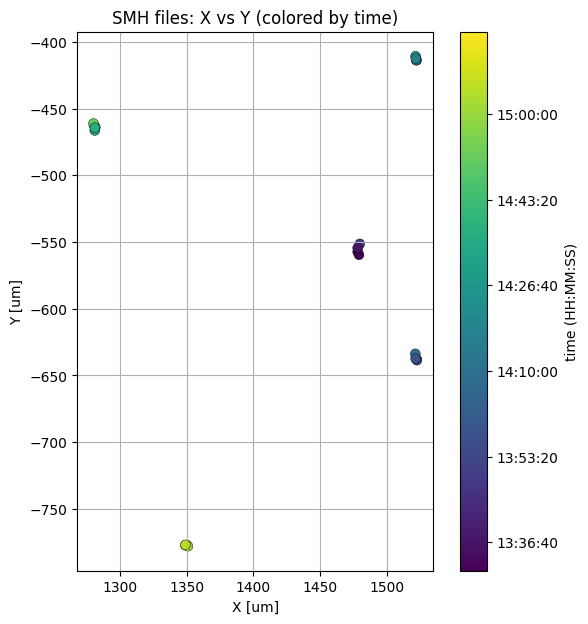

In [12]:
df = pd.DataFrame(smhs)

# Keep only rows with valid xyz_coord_um lists
df = df[df['xyz_coord_um'].notna()].copy()

# extract x, y (assumes [x,y,z] or similar)
df['x'] = df['xyz_coord_um'].apply(lambda v: float(v[0]) if v and len(v) >= 2 else np.nan)
df['y'] = df['xyz_coord_um'].apply(lambda v: float(v[1]) if v and len(v) >= 2 else np.nan)

df['t_seconds'] = df['time'].apply(time_to_seconds)

# drop invalid rows
df_plot = df.dropna(subset=['x', 'y', 't_seconds']).copy()

fig, ax = plt.subplots(figsize=(7,7))
sc = ax.scatter(df_plot['x'], df_plot['y'], c=df_plot['t_seconds'], cmap='viridis', s=50, edgecolor='k', lw=0.3)
cbar = fig.colorbar(sc, ax=ax)

# format colorbar ticks as HH:MM:SS
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: sec_to_hms(val)))
cbar.set_label('time (HH:MM:SS)')

ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
ax.set_title('SMH files: X vs Y (colored by time)')
ax.grid(True)

# enforce aspect ratio 1:1 and preserve it when resizing
ax.set_aspect(1.0)
ax.set_adjustable('box')

plt.show()